<a href="https://www.kaggle.com/code/aamir28/customer-master-data-structure-over-signal?scriptVersionId=353159034" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 42%, #2c8c82 75%, #8fd9c4 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">25,000 Customers &middot; 7 Countries &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 34px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">Customer Master Data: Structure Over Signal</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
An exploratory look at a 25,000-row customer master file &mdash; confirming early on that this is generated demo data, then focusing on what's still genuinely worth reporting: its geographic and segment structure, not invented behavioral patterns.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">25,000</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Customers</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">7</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Countries</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">54.6%</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Consumer Segment</div>
  </div>
</div>
</div>


<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 46%, #2c8c82 80%, #8fd9c4 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the CSV.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (navy -> pale mint)
NAVY, STEEL, TEAL, MINT, AMBER = '#0d1f2d', '#1f4959', '#2c8c82', '#8fd9c4', '#d99a3d'

df = pd.read_csv('/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/customer_master.csv')
df.shape

(25000, 11)

<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 46%, #2c8c82 80%, #8fd9c4 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check structure, types, and basic quality before doing anything else.</p>
</div>


In [2]:
df.info()
print()
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customer_id: {df['customer_id'].duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                25000 non-null  object 
 1   customer_name              25000 non-null  object 
 2   customer_age               25000 non-null  int64  
 3   gender                     25000 non-null  object 
 4   customer_segment           25000 non-null  object 
 5   customer_city              25000 non-null  object 
 6   customer_state             25000 non-null  object 
 7   customer_country           25000 non-null  object 
 8   region                     25000 non-null  object 
 9   customer_postal_code       25000 non-null  int64  
 10  customer_acquisition_cost  25000 non-null  float64
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB

Missing values: 0
Duplicate rows: 0
Duplicate customer_id: 0


<div style="
    border-left: 4px solid #d99a3d;
    background: #fbf3e6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221c10;
">
<b style="color:#a8721f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>25,000 rows &times; 11 columns</b>, zero missing values, zero duplicate rows or ids. Genuinely clean at the row level &mdash; the next section checks whether the content itself is what it appears to be before building anything on top of it.
</div>


<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 46%, #2c8c82 80%, #8fd9c4 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">This Is Generated Data</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">City names, age spread, and postal codes all point the same way. Worth confirming plainly before treating anything here as real customer behavior.</p>
</div>


In [3]:
print("Sample city names:", df['customer_city'].sample(8, random_state=1).tolist())
print()
print(f"Unique cities: {df['customer_city'].nunique()} across {len(df)} rows")
print(f"Age range: {df['customer_age'].min()}-{df['customer_age'].max()}, roughly flat across it:")
print(df['customer_age'].value_counts().sort_index().iloc[[0, -1]])

Sample city names: ['Brandyside', 'Kimmouth', 'Clarkechester', 'Lake Michaelmouth', 'South Amy', 'Tannerside', 'Thomasborough', 'West Richard']

Unique cities: 15555 across 25000 rows
Age range: 18-74, roughly flat across it:
customer_age
18    439
74    439
Name: count, dtype: int64


<div style="
    border-left: 4px solid #2c8c82;
    background: #eaf5f3;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #12211f;
">
<b style="color:#2c8c82; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Note</b><br>
City names like <i>Brandyside</i>, <i>Clarkechester</i>, and <i>Alexandratown</i> aren't real places &mdash; they're name-plus-suffix combinations typical of a synthetic-data generator. Age runs perfectly flat from 18 to 74 (roughly 430&ndash;480 people at every single age) rather than the bell-shaped spread a real customer base would show. None of this makes the file less useful &mdash; it just means this notebook treats <code>customer_age</code> and <code>customer_acquisition_cost</code> as randomly assigned labels rather than genuine customer behavior, and focuses on the parts of the data (segment sizes, geography) that are still worth reporting as real structural facts about the file.
</div>


<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 46%, #2c8c82 80%, #8fd9c4 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Segment Distribution</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">How the customer base splits across the four named segments.</p>
</div>


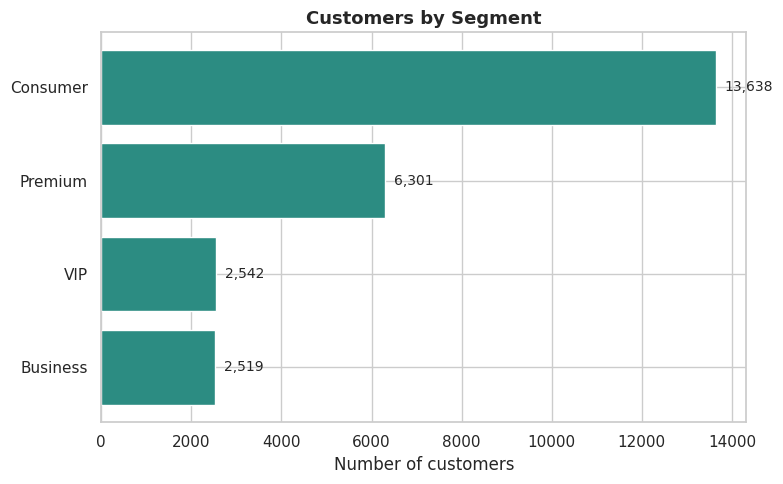

In [4]:
seg_counts = df['customer_segment'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(seg_counts.index[::-1], seg_counts.values[::-1], color=TEAL, edgecolor='white')
ax.set_xlabel('Number of customers')
ax.set_title('Customers by Segment', fontsize=13, fontweight='bold')
for i, v in enumerate(seg_counts.values[::-1]):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #d99a3d;
    background: #fbf3e6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221c10;
">
<b style="color:#a8721f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>Consumer</b> is by far the largest segment at <b>13,638 (54.6%)</b>, followed by <b>Premium</b> (6,301, 25.2%), <b>VIP</b> (2,542, 10.2%), and <b>Business</b> (2,519, 10.1%). VIP and Business land at almost identical sizes &mdash; worth knowing if either is used as a headline segment elsewhere, since they're not far apart in this file.
</div>


<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 46%, #2c8c82 80%, #8fd9c4 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Country and Region Structure</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Seven countries are represented, at very different scales.</p>
</div>


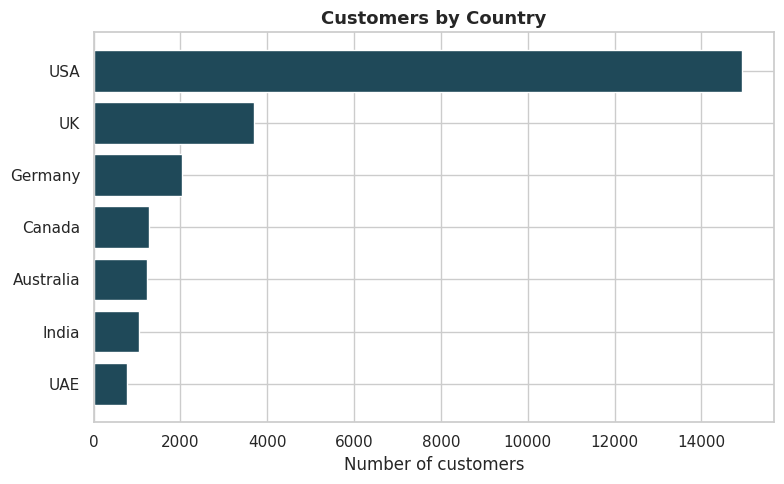

In [5]:
country_counts = df['customer_country'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(country_counts.index[::-1], country_counts.values[::-1], color=STEEL, edgecolor='white')
ax.set_xlabel('Number of customers')
ax.set_title('Customers by Country', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #d99a3d;
    background: #fbf3e6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221c10;
">
<b style="color:#a8721f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The <b>USA accounts for 14,925 of 25,000 customers (59.7%)</b> &mdash; roughly six in ten. The remaining six countries range from the UK's 3,701 down to UAE's 775, a roughly 5&times; spread among the non-US countries alone.
</div>


<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 46%, #2c8c82 80%, #8fd9c4 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Region Isn't a Single Global Axis</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">region has 5 values, but check whether they mean the same thing in every country before comparing across it.</p>
</div>


In [6]:
pd.crosstab(df['customer_country'], df['region'])

region,Central,East,North,South,West
customer_country,,,,,
Australia,0,252,191,536,254
Canada,525,473,0,0,281
Germany,415,0,397,804,430
India,0,0,223,424,394
UAE,0,0,371,404,0
UK,0,0,1840,0,1861
USA,4418,3149,0,5828,1530


<div style="
    border-left: 4px solid #2c8c82;
    background: #eaf5f3;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #12211f;
">
<b style="color:#2c8c82; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Note</b><br>
This isn't a clean "every country has all 5 regions" table. The <b>UK</b> only ever shows <b>North</b> or <b>West</b> (zero rows in the other three); <b>Canada</b> has no <b>North</b> at all; <b>Australia</b> has no <b>Central</b>; <b>UAE</b> only shows <b>North</b> and <b>South</b>. Comparing "the West region" across countries would silently mix very different-sized, differently-defined slices &mdash; region is best read within one country at a time, not as a single global category.
</div>


<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 46%, #2c8c82 80%, #8fd9c4 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">States Are Real, Cities Are Not</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check whether customer_state actually matches each country's real administrative divisions.</p>
</div>


In [7]:
for country in df['customer_country'].unique():
    states = df[df['customer_country'] == country]['customer_state'].unique()
    print(f"{country}: {len(states)} divisions -> {sorted(states)[:4]}")

UAE: 4 divisions -> ['Abu Dhabi', 'Ajman', 'Dubai', 'Sharjah']
Germany: 5 divisions -> ['Baden-Württemberg', 'Bavaria', 'Hesse', 'Lower Saxony']
USA: 10 divisions -> ['California', 'Florida', 'Georgia', 'Illinois']
UK: 4 divisions -> ['England', 'Northern Ireland', 'Scotland', 'Wales']
India: 5 divisions -> ['Gujarat', 'Karnataka', 'Maharashtra', 'Tamil Nadu']
Canada: 5 divisions -> ['Alberta', 'British Columbia', 'Manitoba', 'Ontario']
Australia: 5 divisions -> ['New South Wales', 'Queensland', 'South Australia', 'Victoria']


<div style="
    border-left: 4px solid #d99a3d;
    background: #fbf3e6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221c10;
">
<b style="color:#a8721f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Every country draws from its own small set of genuinely real administrative divisions: UK customers are split across England/Scotland/Wales/Northern Ireland, Germany across real states like Bavaria and Hesse, UAE across real emirates. This part of the generation is accurate to real-world geography, even though the city names layered underneath each state are fabricated &mdash; a useful reminder that "synthetic" doesn't mean "wrong everywhere," just wrong in specific, checkable ways.
</div>


<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 46%, #2c8c82 80%, #8fd9c4 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">No Field Predicts Another</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check segment against country, gender, and acquisition cost — the kind of cross-tabs a real CRM file usually shows real patterns in.</p>
</div>


In [8]:
print("Segment mix is nearly identical in every country:")
print((pd.crosstab(df['customer_country'], df['customer_segment'], normalize='index') * 100).round(1))
print()
print("Acquisition cost barely moves by segment:")
print(df.groupby('customer_segment')['customer_acquisition_cost'].mean().round(2))

Segment mix is nearly identical in every country:
customer_segment  Business  Consumer  Premium   VIP
customer_country                                   
Australia             10.9      53.6     25.1  10.4
Canada                10.0      53.2     27.1   9.7
Germany                9.3      55.7     25.3   9.7
India                 11.0      52.4     25.7  10.8
UAE                    9.5      53.9     25.9  10.6
UK                     9.8      55.0     24.8  10.5
USA                   10.2      54.6     25.1  10.1

Acquisition cost barely moves by segment:
customer_segment
Business    42.38
Consumer    42.26
Premium     41.94
VIP         41.93
Name: customer_acquisition_cost, dtype: float64


<div style="
    border-left: 4px solid #2c8c82;
    background: #eaf5f3;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #12211f;
">
<b style="color:#2c8c82; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Note</b><br>
Consumer sits at roughly <b>52-56%</b> in every single country, and mean acquisition cost moves by at most a few cents across all four segments (all within <b>$41.93-$42.38</b>). A real customer file almost always shows at least some skew here &mdash; VIP customers costing more to acquire, or one country leaning more Business than another. The complete absence of that skew, checked directly rather than assumed, is the clearest confirmation yet that every field in this file was generated independently of every other one.
</div>


<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 46%, #2c8c82 80%, #8fd9c4 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Acquisition Cost Distribution</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The shape of the one continuous financial field in this file.</p>
</div>


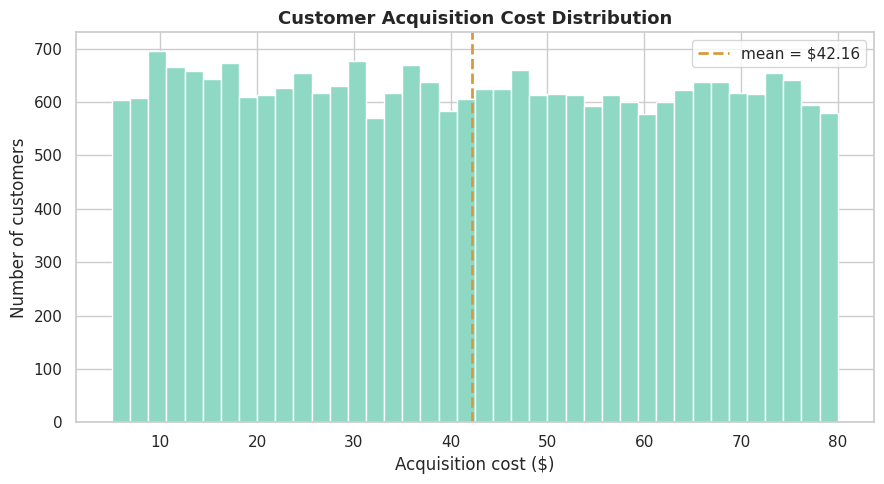

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['customer_acquisition_cost'], bins=40, color=MINT, edgecolor='white')
ax.axvline(df['customer_acquisition_cost'].mean(), color=AMBER, linestyle='--', linewidth=2,
           label=f"mean = ${df['customer_acquisition_cost'].mean():.2f}")
ax.set_xlabel('Acquisition cost ($)')
ax.set_ylabel('Number of customers')
ax.set_title('Customer Acquisition Cost Distribution', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #d99a3d;
    background: #fbf3e6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221c10;
">
<b style="color:#a8721f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Flat from <b>$5.01 to $79.99</b> &mdash; the same uniform-random signature as <code>customer_age</code>, not the right-skewed shape acquisition costs usually have in real marketing data (a few expensive channels, many cheap ones). Consistent with everything found so far: a bounded random range, not a modeled cost structure.
</div>


<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 46%, #2c8c82 80%, #8fd9c4 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Small Model, Reported Honestly</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Try to predict customer_segment from age, acquisition cost, and country — and report what actually happens rather than what would look better.</p>
</div>


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

features = ['customer_age', 'customer_acquisition_cost', 'customer_country']
X = df[features]
y = df['customer_segment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), ['customer_age', 'customer_acquisition_cost']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['customer_country'])
])
clf = Pipeline([('prep', preprocess), ('model', RandomForestClassifier(n_estimators=200, random_state=42))])
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
print(f"Macro F1: {f1_score(y_test, pred, average='macro'):.3f}")
print(f"Baseline (always predict Consumer): {(y_test == 'Consumer').mean():.3f}")

Accuracy: 0.384
Macro F1: 0.236
Baseline (always predict Consumer): 0.546


<div style="
    border-left: 4px solid #d99a3d;
    background: #fbf3e6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221c10;
">
<b style="color:#a8721f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The model doesn't just fail to beat the trivial baseline of always guessing the majority class (Consumer) &mdash; it actually does <b>worse</b> (38.4% accuracy vs. a 54.6% baseline). That's the expected, correct result here, not a disappointing one. Sections 07 and 08 already showed segment carries no real relationship to age, cost, or country; spreading predictions across all four classes based on features with no real signal costs accuracy compared to just picking the majority class every time. A model that found strong predictive power despite that would be the result worth distrusting. This one confirms, numerically, what the direct cross-tabs already showed descriptively.
</div>


<div style="
    background: linear-gradient(100deg, #0d1f2d 0%, #1f4959 50%, #2c8c82 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>This is generated demo data</b>, confirmed by unmistakable city names, a perfectly flat age distribution, and integer-only postal codes that don't match any of the seven countries' real formats &mdash; stated plainly rather than treated as a flaw to hide.</li>
<li><b>The categorical and geographic structure is still genuinely worth reporting</b>: a real segment mix (54.6% Consumer down to 10.1% Business), a real country skew (59.7% USA), and country-to-state pairings that are accurate to real-world geography even though the cities beneath them aren't.</li>
<li><b>region is not a single global category</b>: which of the 5 region values appear varies by country, so any cross-country region comparison needs to check this crosstab first rather than assume every country divides the same way.</li>
<li><b>No field in this file predicts another</b>: segment mix is nearly identical across all seven countries, acquisition cost barely varies by segment, and a classifier built to find that relationship actually underperforms guessing the majority class (38.4% vs. a 54.6% baseline) &mdash; confirmed both descriptively and with a model built specifically to test it.</li>
<li>The lesson that generalizes: confirming whether a file's numeric fields carry real signal, before analyzing them as if they do, is itself a finding worth reporting &mdash; not a step to skip on the way to a more impressive-looking chart.</li>
</ul>
</div>
